In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [ ]:
load_dotenv()
from langchain_groq import ChatGroq
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1
)

In [11]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str
    rating: float

In [18]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [19]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title under 300 words- {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [20]:
def evaluate_blog(state: BlogState) -> BlogState:

    outline = state['outline']
    blog = state['content']

    prompt = f'Based on outline {outline} rate the blog {blog} between 0.0 and 10.0'

    rating = model.invoke(prompt).content

    state['rating']= rating

    return state

In [21]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()


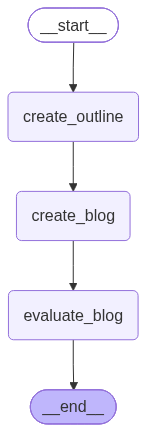

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [23]:
intial_state = {'title': 'Rise of Pollution in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of Pollution in India', 'outline': '**Blog Title:** *The Rise of Pollution in India: Causes, Consequences, and the Road Ahead*  \n\n---\n\n## 1. Introduction  \n- **Hook:** A striking statistic or anecdote (e.g., “Delhi’s air quality index hit 500+ in November 2023 – a level considered hazardous for human health”).  \n- **Why it matters:** Briefly explain the relevance of pollution to public health, the economy, and India’s global image.  \n- **Scope of the post:** Outline what will be covered – types of pollution, key drivers, impacts, current policies, and actionable solutions.  \n\n---\n\n## 2. Understanding Pollution: Definitions & Categories  \n### 2.1 Air Pollution  \n- Particulate Matter (PM₂.₅, PM₁₀)  \n- Nitrogen oxides (NOₓ), Sulphur dioxide (SO₂)  \n- Ozone (O₃) and volatile organic compounds (VOCs)  \n\n### 2.2 Water Pollution  \n- Industrial effluents (heavy metals, chemicals)  \n- Agricultural runoff (nitrates, phosphates, pesticides)  \n- Domestic sewage 

In [24]:
print(final_state['outline'])

**Blog Title:** *The Rise of Pollution in India: Causes, Consequences, and the Road Ahead*  

---

## 1. Introduction  
- **Hook:** A striking statistic or anecdote (e.g., “Delhi’s air quality index hit 500+ in November 2023 – a level considered hazardous for human health”).  
- **Why it matters:** Briefly explain the relevance of pollution to public health, the economy, and India’s global image.  
- **Scope of the post:** Outline what will be covered – types of pollution, key drivers, impacts, current policies, and actionable solutions.  

---

## 2. Understanding Pollution: Definitions & Categories  
### 2.1 Air Pollution  
- Particulate Matter (PM₂.₅, PM₁₀)  
- Nitrogen oxides (NOₓ), Sulphur dioxide (SO₂)  
- Ozone (O₃) and volatile organic compounds (VOCs)  

### 2.2 Water Pollution  
- Industrial effluents (heavy metals, chemicals)  
- Agricultural runoff (nitrates, phosphates, pesticides)  
- Domestic sewage & plastic waste  

### 2.3 Soil & Land Pollution  
- Improper waste disp

In [25]:
print(final_state['content'])

**The Rise of Pollution in India: Causes, Consequences, and the Road Ahead**

---

### 1. Introduction  
In November 2023 Delhi’s Air‑Quality Index surged past **500**, a level deemed hazardous for human health. Pollution now threatens public health, drags down the economy, and tarnishes India’s global image. This post surveys the main types of pollution, their drivers, impacts, policy responses, and what can be done next.

### 2. Pollution – What We’re Facing  
- **Air:** PM₂.₅/PM₁₀, NOₓ, SO₂, O₃, VOCs.  
- **Water:** Industrial effluents, agricultural runoff, sewage, plastics.  
- **Soil/Land:** Landfill leachate, chemical fertilizers, e‑waste.  
- **Noise & Light:** Urban traffic, construction, excessive street lighting.

### 3. How It Evolved  
- **Pre‑1947:** Minimal industry, low emissions.  
- **Post‑1990 liberalization:** Manufacturing, cars, and cities exploded.  
- **2010‑2024:** Megacities, frequent smog, climate‑linked heatwaves.  

### 4. Why Pollution Is Rising  
1. **Urb

In [26]:
print(final_state['rating'])

**Rating: 8.7 / 10**

### Why it scores high
| Criterion | Assessment |
|-----------|------------|
| **Structure & Flow** | The post follows a logical, reader‑friendly outline (intro → definitions → history → drivers → data → impacts → policy → solutions → roadmap → call‑to‑action). Headings and sub‑headings make it easy to skim. |
| **Comprehensiveness** | Covers all major pollution media (air, water, soil, noise/light) and ties them to economic, health, and equity impacts. Includes historical context, quantitative tables, and a clear roadmap. |
| **Use of Data & Visual Aids** | Provides up‑to‑date statistics, a comparative table, and suggestions for graphs/maps. Data sources are cited (CPCB, WHO, Lancet, UNEP). |
| **Clarity & Readability** | Plain‑language explanations, bullet points, and short paragraphs keep the narrative accessible to a broad audience. |
| **Actionability** | Ends with concrete steps for individuals, communities, and policymakers, encouraging engagement. |
| **Cr